<a href="https://colab.research.google.com/github/dataprogpy/code-samples/blob/main/starter_files/09_time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Analysis

In [1]:
!pip install statsmodels pmdarima

In [1]:
!pip install pmdarima

In [22]:
import datetime as dt

import polars as pl
import pandas as pd
import yfinance as yf

import altair as alt
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
from pmdarima import auto_arima
from pmdarima import model_selection

## Data Wrangling and Exploratory Data Analysis

In [4]:
df_missing = pl.DataFrame({
    "date": [dt.date(2024, 1, 1), dt.date(2024, 1, 2), dt.date(2024, 1, 3)],
    "value": [10, None, 15]
})

df = (
    df_missing
    .with_columns(
        pl.col("value")
        .fill_null(strategy="forward")
        .alias("value_forward")
        )
    .with_columns(
        pl.col("value")
        .fill_null(strategy="backward")
        .alias("value_backward")
    )
    .with_columns(
        pl.col("value")
        .fill_null(strategy="mean")
        .alias("value_mean")
    )
)
df

date,value,value_forward,value_backward,value_mean
date,i64,i64,i64,i64
2024-01-01,10,10,10,10
2024-01-02,null,10,15,12
2024-01-03,15,15,15,15


In [5]:
# Example DataFrame with daily data
df_daily = pl.DataFrame({
    "date": pl.date_range(dt.date(2024, 1, 1), dt.date(2024, 2, 15), "1d", eager=True),
    "sales": range(46)
})

# Downsample to monthly average sales
df_monthly = df_daily.group_by_dynamic(
    "date", every="1mo"
).agg(
    pl.col("sales").mean().alias("average_sales")
)
display(df_monthly)

date,average_sales
date,f64
2024-01-01,15.0
2024-02-01,38.0


In [6]:
# Define the ticker symbol and date range
ticker = 'GOOG'
start_date = '2019-01-01'
end_date = '2025-06-01'

# Download the data using yfinance
df = yf.download(ticker, start=start_date, end=end_date)

# Display the first few rows of the DataFrame
display(df.head())
df_pl = pl.from_pandas(df, include_index=True )
df_pl.columns

/tmp/ipython-input-6-3659620356.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2019-01-02,51.983498,52.305088,50.485403,50.528148,30652000
2019-01-03,50.502804,52.536712,50.403889,51.742433,36822000
2019-01-04,53.219158,53.225620,51.067348,51.324422,41878000
2019-01-07,53.103840,53.382685,52.426367,53.258423,39638000
2019-01-08,53.496010,53.907565,52.713165,53.487561,35298000


['Date',
 "('Close', 'GOOG')",
 "('High', 'GOOG')",
 "('Low', 'GOOG')",
 "('Open', 'GOOG')",
 "('Volume', 'GOOG')"]

In [7]:
def colname(col: str):
  if col.startswith('('):
        return ( col
          .lstrip('(')
          .rstrip(')')
          .split(",")[0]
          .strip("'")
          .lower()
        )
  return col.lower()

print([colname(col) for col in df_pl.columns])

df_pl = df_pl.rename(colname)
df_pl.head()

['date', 'close', 'high', 'low', 'open', 'volume']


date,close,high,low,open,volume
datetime[ns],f64,f64,f64,f64,i64
2019-01-02 00:00:00,51.983498,52.305088,50.485403,50.528148,30652000
2019-01-03 00:00:00,50.502804,52.536712,50.403889,51.742433,36822000
2019-01-04 00:00:00,53.219158,53.22562,51.067348,51.324422,41878000
2019-01-07 00:00:00,53.10384,53.382685,52.426367,53.258423,39638000
2019-01-08 00:00:00,53.49601,53.907565,52.713165,53.487561,35298000


In [8]:
alt.Chart(df_pl).mark_line().encode(
    x='date',
    y='close',
    tooltip=['date', 'close']
).properties(
    width=800,
    height=400
)

alt.Chart(...)

### Filtering data based on temporal properties

In [9]:
alt.Chart(
    df_pl.filter(
         pl.col("date").is_between(
             dt.datetime(2020, 1, 1),
             dt.datetime(2022, 12, 31)
             )
    )
    ).mark_line().encode(
    x='date',
    y='close',
    tooltip=['date', 'close']
).properties(
    width=800,
    height=400
)

alt.Chart(...)

In [10]:
# Calculate 30-day and 90-day moving averages
df_with_ma = df_pl.with_columns(
    pl.col("close").rolling_mean(window_size=30).alias("ma_30_day"),
    pl.col("close").rolling_mean(window_size=90).alias("ma_90_day")
)
# Plot the daily closing price
base = alt.Chart(df_with_ma).encode(x='date:T')

closing_price = base.mark_line().encode(
    y=alt.Y('close:Q', title='Closing Price (USD)')
).properties(
    title='Google (GOOG) Daily Stock Price',
    width=800,
    height=400,
)

# Create layers for the moving averages
ma_30 = base.mark_line(color='orange').encode(
    y='ma_30_day:Q'
)

ma_90 = base.mark_line(color='red').encode(
    y='ma_90_day:Q'
)

# Combine the original price plot with the moving average plots
(closing_price + ma_30 + ma_90)

alt.LayerChart(...)

## Visual Exploration of Trend and Seasonlity

In [11]:
df_ap = pl.read_csv("/content/drive/MyDrive/dataprogpy/data/AirPassengers.csv")

df_ap = df_ap.with_columns(
    pl.col("Month").str.strptime(pl.Date, format="%Y-%m").alias("month_dt"),
    pl.col("#Passengers").rolling_mean(window_size=12).alias("ma_12_month"),
).with_columns(
    pl.col("month_dt").dt.month().alias("season"),
    (pl.col("#Passengers")/pl.col("ma_12_month")).alias("detrended")
).select(
    pl.col("month_dt","season","ma_12_month","detrended" ),
    pl.col("#Passengers").alias("passengers")
)

df_ap.tail()

month_dt,season,ma_12_month,detrended,passengers
date,i8,f64,f64,i64
1960-08-01,8,463.333333,1.307914,606
1960-09-01,9,467.083333,1.0876,508
1960-10-01,10,471.583333,0.977558,461
1960-11-01,11,473.916667,0.822929,390
1960-12-01,12,476.166667,0.907245,432


In [12]:
base = alt.Chart(df_ap)

full = base.mark_line().encode(
    alt.X('month_dt:T'),
    alt.Y('passengers:Q'),
    tooltip=['month_dt', 'passengers']
).properties(
    width=800,
    height=400
)

ma_12_month = full.mark_line(color='orange').encode(
    alt.Y('ma_12_month:Q'),
)

detrended = full.mark_line(color='red').encode(
    alt.Y('detrended:Q').scale(zero=False)
)

seasonlity = (
    full
    .mark_boxplot()
    .encode(
        alt.X('season:O'),
        alt.Y('detrended:Q').scale(zero=False),
    )
)

display(full + ma_12_month )
display(detrended)
display(seasonlity)

alt.LayerChart(...)

alt.Chart(...)

alt.Chart(...)

In [13]:

df = pd.read_csv("/content/drive/MyDrive/dataprogpy/data/AirPassengers.csv", parse_dates=[0])
df.columns = ["month", "passengers"]
df.set_index("month", inplace=True)
df.head()

,passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


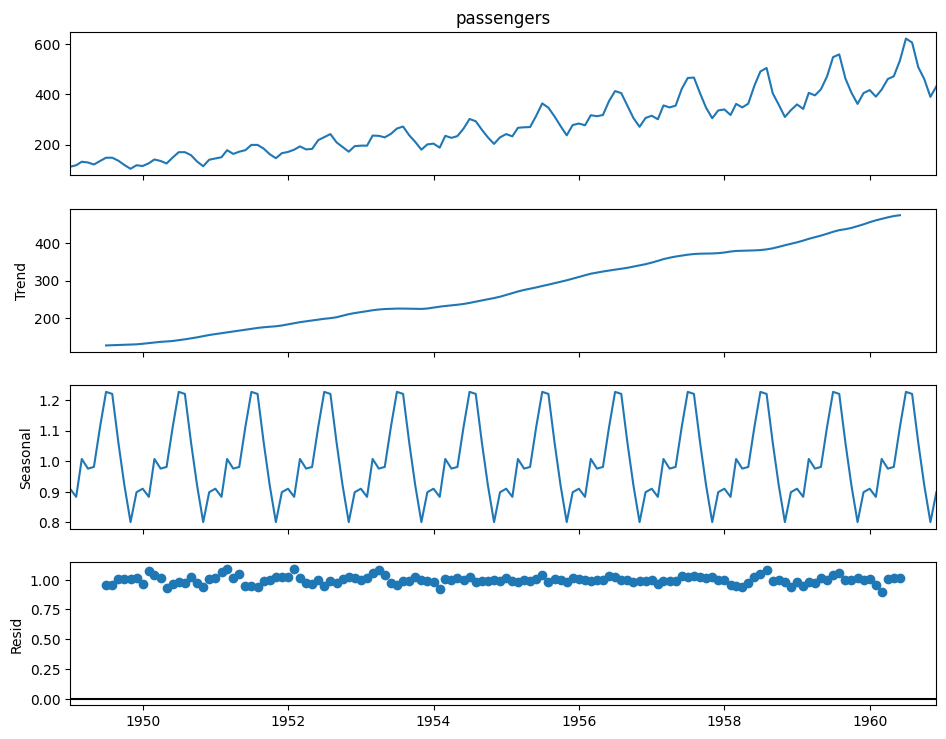

In [14]:
decomposition = sm.tsa.seasonal_decompose(df['passengers'], model='multiplicative', period=12)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

<Axes: xlabel='month'>

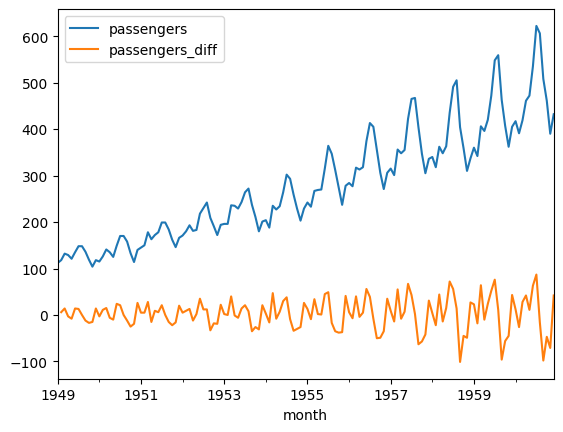

In [15]:
df_diff = df.copy()
df_diff['passengers_diff'] = df_diff['passengers'].diff()

df_diff.plot()



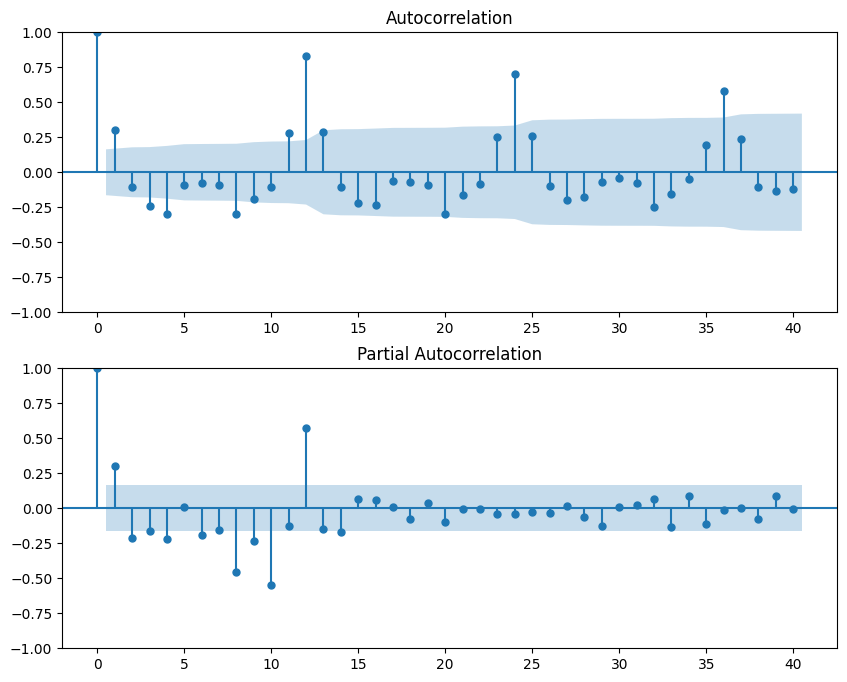

In [16]:
differenced_series = df['passengers'].diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(differenced_series, ax=ax1, lags=40)
plot_pacf(differenced_series, ax=ax2, lags=40)

plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  143
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -694.061
Date:                Thu, 17 Jul 2025   AIC                           1396.122
Time:                        04:49:20   BIC                           1407.973
Sample:                    02-01-1949   HQIC                          1400.937
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4507      3.441      0.712      0.476      -4.293       9.195
ar.L1         -0.4767      0.128     -3.735      0.000      -0.727      -0.227
ma.L1          0.8645      0.080     10.743      0.0

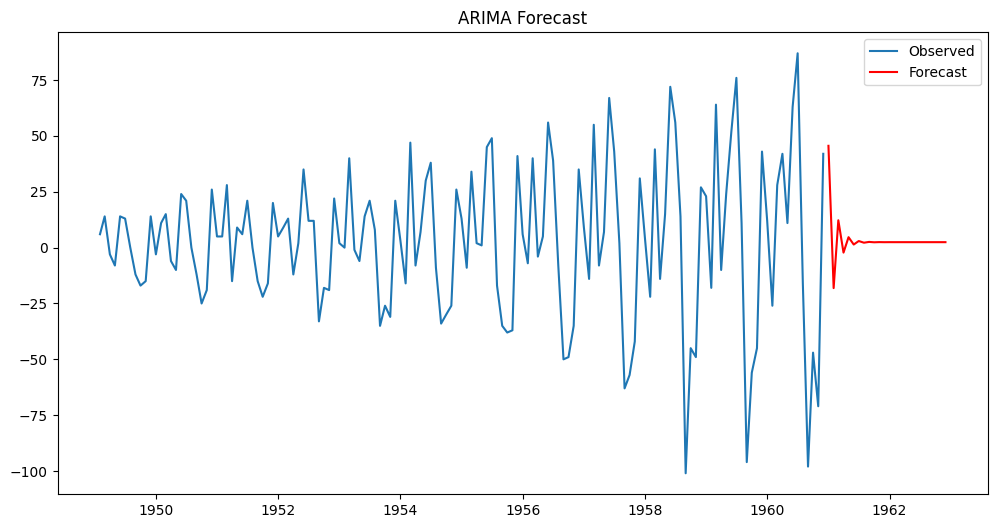

In [17]:
model = sm.tsa.ARIMA(differenced_series, order=(1, 0, 1))
results = model.fit()

# Print the model summary
print(results.summary())

# Generate forecasts
forecast_steps = 24
forecast = results.forecast(steps=forecast_steps)

# Plot the original series and the forecast
plt.figure(figsize=(12, 6))
plt.plot(differenced_series, label='Observed')
plt.plot(forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()

In [20]:

series = df['passengers'].to_numpy()

auto_model = auto_arima(series,
                           start_p=1, start_q=1,
                           test='adf',       # use adf test to find optimal 'd'
                           max_p=3, max_q=3, # maximum p and q
                           m=12,             # frequency of the series
                           d=None,           # let model determine 'd'
                           seasonal=True,    # Fit a seasonal model (SARIMA)
                           start_P=0,
                           D=1,              # let model determine 'D'
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)    # use stepwise algorithm to find best model

# Print the model summary
print(auto_model.summary())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Thu, 17 Jul 2025   AIC                           1019.178
Time:                                     04:53:24   BIC                           1030.679
Sample:                                          0   HQIC                          1023.851
                                             - 144                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      

In [21]:
stepwise_fit = auto_arima(df['passengers'], start_p = 1, start_q = 1,
                          max_p = 3, max_q = 3, m = 12,
                          start_P = 0, seasonal = True,
                          d = None, D = 1, trace = True,
                          error_action ='ignore',
                          suppress_warnings = True,
                          stepwise = True)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1022.896, Time=0.90 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.07 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.44 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,1,2)(2,1,0)[12]             : AIC=1021.148, Time=0.49 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(2,1,0)[12]             : AIC=1022.805, Time=0.91 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(2,1,0)[12] intercept   : AIC=1021.017, Time=0.82 sec

Best model:  ARIMA(0,1,1)(2,1,0)[12]          
Total fit time: 18.395 seconds


In [23]:
train = df.iloc[:len(df)-12]
test = df.iloc[len(df)-12:]

model = SARIMAX(df['passengers'],order=(0,1,1),seasonal_order=(2,1,0,12))

result = model.fit()
result.summary()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                          passengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Thu, 17 Jul 2025   AIC                           1019.178
Time:                                     04:56:48   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372      0.170      -0.301       0.053
ar.S.L24       0.1911      0.107      1.783      0.075      -0.019       0.401
sigma2       130.4480     15.527      8.402      0.000     100.016     160.880
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.59
Prob(Q):                              0.92   Prob(JB):                         0.10
Heteroskedasticity (H):               2.70   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""